omega=0.5: iterations(par)=255, time(par)=4.573s, final_err=9.455e-10
omega=1.0: iterations(par)=123, time(par)=2.749s, final_err=9.086e-10
omega=1.2: iterations(par)=215, time(par)=3.001s, final_err=9.957e-10


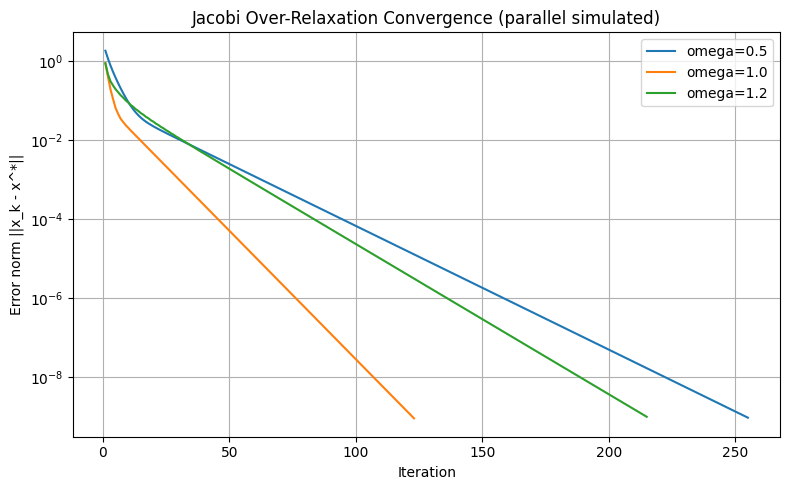

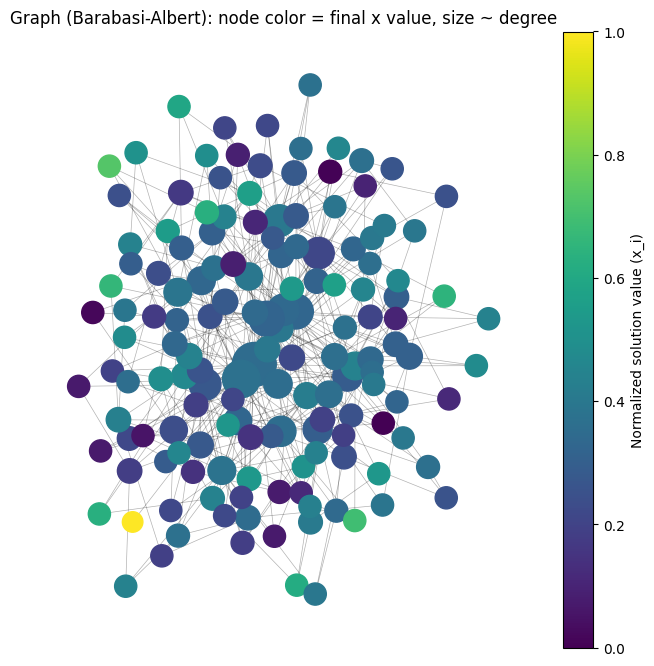


Top 10 nodes by degree (degree, x_final):
    degree   x_final
0     44.0  0.023191
4     29.0  0.054357
1     24.0 -0.011149
13    24.0 -0.028755
7     18.0 -0.100115
24    18.0  0.107976
20    17.0 -0.197521
8     17.0  0.005096
9     15.0  0.031343
5     14.0 -0.078752

Summary:
Nodes: 150, Edges: 441, Omegas tested: [0.5, 1.0, 1.2]


In [ ]:
#!/usr/bin/env python3
# jacobi_graph_sim.py
# Simulate Jacobi over-relaxation on a graph and visualize structure + convergence.

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor
import time
import pandas as pd

# ---------- Parameters ----------
n = 150       # number of nodes
m = 3         # BA parameter (edges per new node)
np.random.seed(0)

# ---------- Build graph ----------
G = nx.barabasi_albert_graph(n, m, seed=1)
A_adj = nx.to_numpy_array(G, dtype=float)
deg = A_adj.sum(axis=1)

# Build matrix A = I + Laplacian = diag(deg)+I - adjacency
A = np.diag(deg + 1.0) - A_adj  # A_ii = deg_i + 1, A_ij = -1 if edge exists

# Right-hand side
b = np.random.randn(n)
b = b - b.mean()

# Exact solution for error reference
x_exact = np.linalg.solve(A, b)

# ---------- Parallel Jacobi over-relaxation ----------
def jacobi_over_relaxation_parallel(A, b, omega=1.0, max_iter=500, tol=1e-8, n_workers=8):
    n = A.shape[0]
    x = np.zeros(n)
    D = np.diag(A).copy()
    R = A.copy()
    np.fill_diagonal(R, 0.0)
    history = []
    for k in range(max_iter):
        x_old = x.copy()
        new_x = np.zeros(n)
        def compute_i(i):
            s = b[i] - np.dot(R[i, :], x_old)
            return (1 - omega) * x_old[i] + omega * (s / D[i])
        with ThreadPoolExecutor(max_workers=n_workers) as ex:
            futures = [ex.submit(compute_i, i) for i in range(n)]
            for i, fut in enumerate(futures):
                new_x[i] = fut.result()
        x = new_x
        err = np.linalg.norm(x - x_exact)
        history.append(err)
        if err < tol:
            break
    return x, np.array(history)

# ---------- Vectorized Jacobi (reference) ----------
def jacobi_over_relaxation_vectorized(A, b, omega=1.0, max_iter=500, tol=1e-8):
    n = A.shape[0]
    x = np.zeros(n)
    D = np.diag(A).copy()
    R = A.copy()
    np.fill_diagonal(R, 0.0)
    history = []
    for k in range(max_iter):
        x_old = x.copy()
        s = b - R.dot(x_old)
        x = (1 - omega) * x_old + omega * (s / D)
        err = np.linalg.norm(x - x_exact)
        history.append(err)
        if err < tol:
            break
    return x, np.array(history)

# ---------- Run experiments ----------
omegas = [0.5, 1.0, 1.2]
results = {}
for omega in omegas:
    start = time.time()
    x_par, hist_par = jacobi_over_relaxation_parallel(A, b, omega=omega, max_iter=1000, tol=1e-9, n_workers=8)
    t_par = time.time() - start
    x_vec, hist_vec = jacobi_over_relaxation_vectorized(A, b, omega=omega, max_iter=1000, tol=1e-9)
    results[omega] = {'par': {'x': x_par, 'hist': hist_par, 'time': t_par},
                      'vec': {'x': x_vec, 'hist': hist_vec}}
    print(f"omega={omega}: iterations(par)={len(hist_par)}, time(par)={t_par:.3f}s, final_err={hist_par[-1]:.3e}")

# ---------- Plot convergence histories ----------
plt.figure(figsize=(8,5))
for omega in omegas:
    h = results[omega]['par']['hist']
    plt.semilogy(np.arange(1, len(h)+1), h, label=f"omega={omega}")
plt.xlabel("Iteration")
plt.ylabel("Error norm ||x_k - x^*||")
plt.title("Jacobi Over-Relaxation Convergence (parallel simulated)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ---------- Visualize graph (final x values for omega=1.0) ----------
omega_show = 1.0
x_final = results[omega_show]['par']['x']
vals = (x_final - x_final.min()) / (x_final.max() - x_final.min() + 1e-12)
pos = nx.spring_layout(G, seed=2, k=0.12)

plt.figure(figsize=(8,8))
node_sizes = 200 + 800 * (deg / deg.max())
nx.draw_networkx_edges(G, pos, alpha=0.3, width=0.5)
nodes = nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=vals, cmap='viridis')
plt.colorbar(nodes, label='Normalized solution value (x_i)')
plt.title("Graph (Barabasi-Albert): node color = final x value, size ~ degree")
plt.axis('off')
plt.show()

# ---------- Table of top nodes by degree ----------
deg_series = pd.Series(deg, name='degree')
x_series = pd.Series(x_final, name='x_final')
df = pd.concat([deg_series, x_series], axis=1).sort_values('degree', ascending=False).head(10)
print("\nTop 10 nodes by degree (degree, x_final):")
print(df.to_string())

# Summary
print("\nSummary:")
print(f"Nodes: {n}, Edges: {G.number_of_edges()}, Omegas tested: {omegas}")


# Karate graph dataset

Jacobi over-relaxation converged in 277 iterations, final error = 9.752e-10


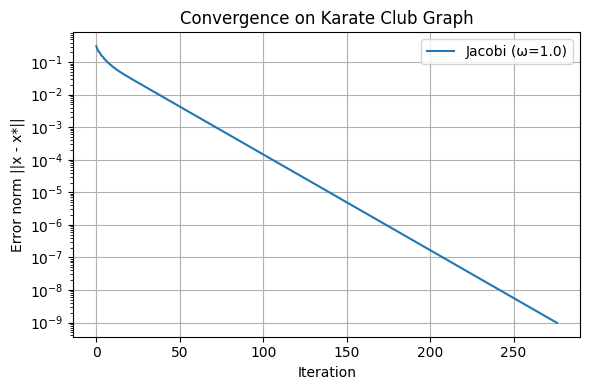

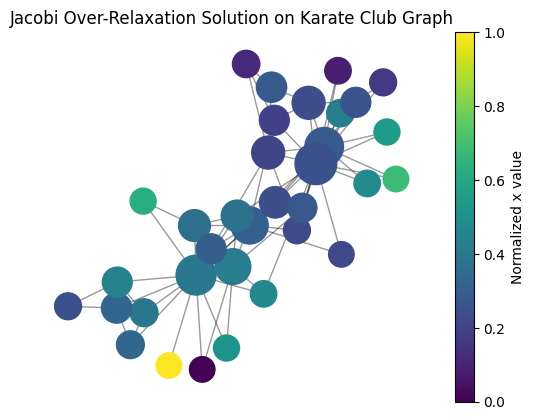

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor

# ----- 1. Load Karate Club graph -----
G = nx.karate_club_graph()
n = G.number_of_nodes()
A_adj = nx.to_numpy_array(G, dtype=float)
deg = A_adj.sum(axis=1)

# ----- 2. Build linear system -----
A = np.diag(deg + 1.0) - A_adj   # A = I + Laplacian
b = np.random.randn(n)
b -= b.mean()  # zero mean for balance

# exact solution for reference
x_exact = np.linalg.solve(A, b)

# ----- 3. Jacobi Over-Relaxation -----
def jacobi_over_relaxation_parallel(A, b, omega=1.0, max_iter=500, tol=1e-8, n_workers=8):
    n = A.shape[0]
    x = np.zeros(n)
    D = np.diag(A).copy()
    R = A.copy()
    np.fill_diagonal(R, 0.0)
    history = []
    for k in range(max_iter):
        x_old = x.copy()
        new_x = np.zeros(n)
        def compute_i(i):
            s = b[i] - np.dot(R[i, :], x_old)
            return (1 - omega) * x_old[i] + omega * (s / D[i])
        with ThreadPoolExecutor(max_workers=n_workers) as ex:
            futures = [ex.submit(compute_i, i) for i in range(n)]
            for i, fut in enumerate(futures):
                new_x[i] = fut.result()
        x = new_x
        err = np.linalg.norm(x - x_exact)
        history.append(err)
        if err < tol:
            break
    return x, np.array(history)

# ----- 4. Run experiment -----
omega = 1.0
x_final, hist = jacobi_over_relaxation_parallel(A, b, omega=omega, max_iter=1000, tol=1e-9)
print(f"Jacobi over-relaxation converged in {len(hist)} iterations, final error = {hist[-1]:.3e}")

# ----- 5. Plot convergence -----
plt.figure(figsize=(6,4))
plt.semilogy(hist, label=f"Jacobi (ω={omega})")
plt.xlabel("Iteration")
plt.ylabel("Error norm ||x - x*||")
plt.title("Convergence on Karate Club Graph")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ----- 6. Visualize graph -----
vals = (x_final - x_final.min()) / (x_final.max() - x_final.min() + 1e-12)
pos = nx.spring_layout(G, seed=2)
node_sizes = 300 + 600 * (deg / deg.max())
nx.draw_networkx_edges(G, pos, alpha=0.4, width=1.0)
nodes = nx.draw_networkx_nodes(G, pos, node_color=vals, cmap='viridis', node_size=node_sizes)
plt.colorbar(nodes, label="Normalized x value")
plt.title("Jacobi Over-Relaxation Solution on Karate Club Graph")
plt.axis('off')
plt.show()


# karate v2

Jacobi ω=0.5: 454 iters, time=2.67s, final err=9.830e-09
Jacobi ω=1.0: 223 iters, time=0.54s, final err=9.936e-09
Jacobi ω=1.2: 546 iters, time=1.29s, final err=9.973e-09
Gauss-Seidel: 109 iters, time=0.02s, final err=9.472e-09


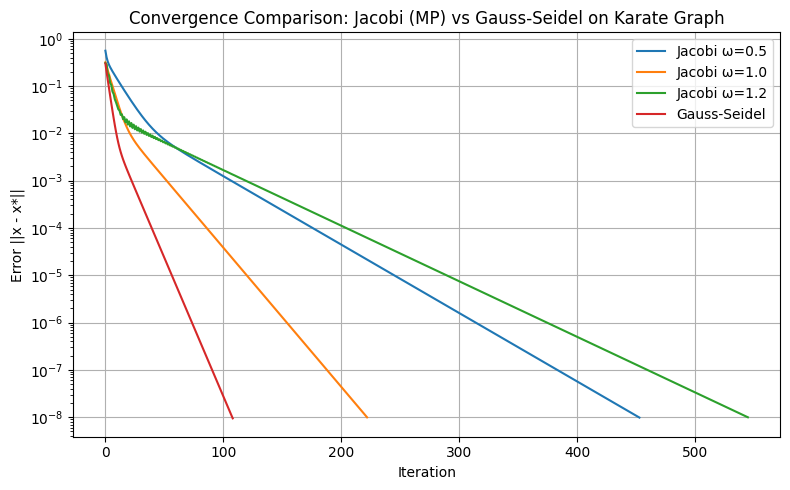

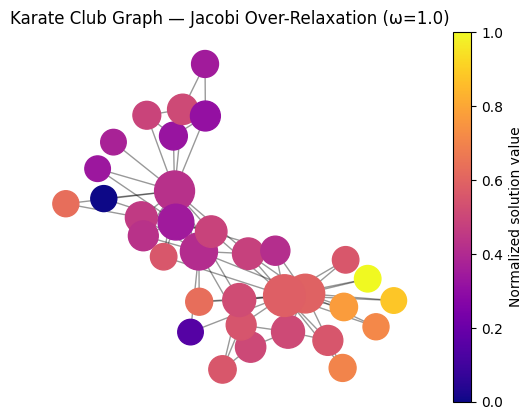

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from multiprocessing import Pool, cpu_count
import time

# ---------------------------
# 1. Build Karate Club Graph
# ---------------------------
G = nx.karate_club_graph()
n = G.number_of_nodes()
A_adj = nx.to_numpy_array(G, dtype=float)
deg = A_adj.sum(axis=1)

# System: A = I + Laplacian
A = np.diag(deg + 1.0) - A_adj
b = np.random.randn(n)
b -= b.mean()  # zero mean

# Exact solution
x_exact = np.linalg.solve(A, b)


# ---------------------------
# 2. Helper functions
# ---------------------------
def jacobi_worker(args):
    """Compute one element update in parallel."""
    i, A_row, D_ii, b_i, x_old, omega = args
    s = b_i - np.dot(A_row, x_old) + D_ii * x_old[i]
    return (1 - omega) * x_old[i] + omega * (s / D_ii)


def jacobi_over_relaxation_mp(A, b, omega=1.0, max_iter=500, tol=1e-8):
    """Jacobi over-relaxation with multiprocessing."""
    n = A.shape[0]
    x = np.zeros(n)
    D = np.diag(A)
    pool = Pool(processes=min(cpu_count(), 8))
    history = []

    for k in range(max_iter):
        args = [(i, A[i, :], D[i], b[i], x, omega) for i in range(n)]
        new_x = pool.map(jacobi_worker, args)
        new_x = np.array(new_x)
        err = np.linalg.norm(new_x - x_exact)
        history.append(err)
        if err < tol:
            break
        x = new_x

    pool.close()
    pool.join()
    return x, np.array(history)


def gauss_seidel(A, b, max_iter=500, tol=1e-8):
    """Sequential Gauss-Seidel iteration."""
    n = A.shape[0]
    x = np.zeros(n)
    history = []

    for k in range(max_iter):
        x_old = x.copy()
        for i in range(n):
            s1 = np.dot(A[i, :i], x[:i])
            s2 = np.dot(A[i, i+1:], x_old[i+1:])
            x[i] = (b[i] - s1 - s2) / A[i, i]
        err = np.linalg.norm(x - x_exact)
        history.append(err)
        if err < tol:
            break
    return x, np.array(history)


# ---------------------------
# 3. Run Experiments
# ---------------------------
omegas = [0.5, 1.0, 1.2]
results = {}

for omega in omegas:
    start = time.time()
    x_jacobi, hist_jacobi = jacobi_over_relaxation_mp(A, b, omega=omega, max_iter=1000)
    t = time.time() - start
    results[f"Jacobi ω={omega}"] = (hist_jacobi, t)
    print(f"Jacobi ω={omega}: {len(hist_jacobi)} iters, time={t:.2f}s, final err={hist_jacobi[-1]:.3e}")

# Gauss-Seidel baseline
start = time.time()
x_gs, hist_gs = gauss_seidel(A, b, max_iter=1000)
t = time.time() - start
results["Gauss-Seidel"] = (hist_gs, t)
print(f"Gauss-Seidel: {len(hist_gs)} iters, time={t:.2f}s, final err={hist_gs[-1]:.3e}")


# ---------------------------
# 4. Plot convergence
# ---------------------------
plt.figure(figsize=(8,5))
for name, (hist, _) in results.items():
    plt.semilogy(hist, label=name)
plt.xlabel("Iteration")
plt.ylabel("Error ||x - x*||")
plt.title("Convergence Comparison: Jacobi (MP) vs Gauss-Seidel on Karate Graph")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ---------------------------
# 5. Visualize graph
# ---------------------------
vals = (x_jacobi - x_jacobi.min()) / (x_jacobi.max() - x_jacobi.min() + 1e-12)
pos = nx.spring_layout(G, seed=1)
node_sizes = 300 + 600 * (deg / deg.max())
nx.draw_networkx_edges(G, pos, alpha=0.4, width=1.0)
nodes = nx.draw_networkx_nodes(G, pos, node_color=vals, cmap='plasma', node_size=node_sizes)
plt.colorbar(nodes, label='Normalized solution value')
plt.title("Karate Club Graph — Jacobi Over-Relaxation (ω=1.0)")
plt.axis('off')
plt.show()


Matrix Properties:
Size: 8 × 8
Strictly diagonally dominant: True
Condition number: 5.9857

Spectral radius of Jacobi matrix (ρ_J): 0.7500
Theoretical bound for ω: 0 < ω < 1.1429
ω = 0.50: ρ(T_ω) = 0.8405 (Converges)
ω = 1.00: ρ(T_ω) = 0.6811 (Converges)
ω = 1.30: ρ(T_ω) = 1.1854 (Diverges)
ω = 1.70: ρ(T_ω) = 1.8578 (Diverges)
ω = 2.00: ρ(T_ω) = 2.3621 (Diverges)
Converged in 123 iterations
Converged in 61 iterations


/tmp/ipython-input-2064329667.py:35: RuntimeWarning: overflow encountered in matmul
  error = np.linalg.norm(A @ x_new - b)
/tmp/ipython-input-2064329667.py:32: RuntimeWarning: overflow encountered in matmul
  x_new = (1 - omega) * x + omega * D_inv @ (b - R @ x)
/tmp/ipython-input-2064329667.py:32: RuntimeWarning: invalid value encountered in matmul
  x_new = (1 - omega) * x + omega * D_inv @ (b - R @ x)


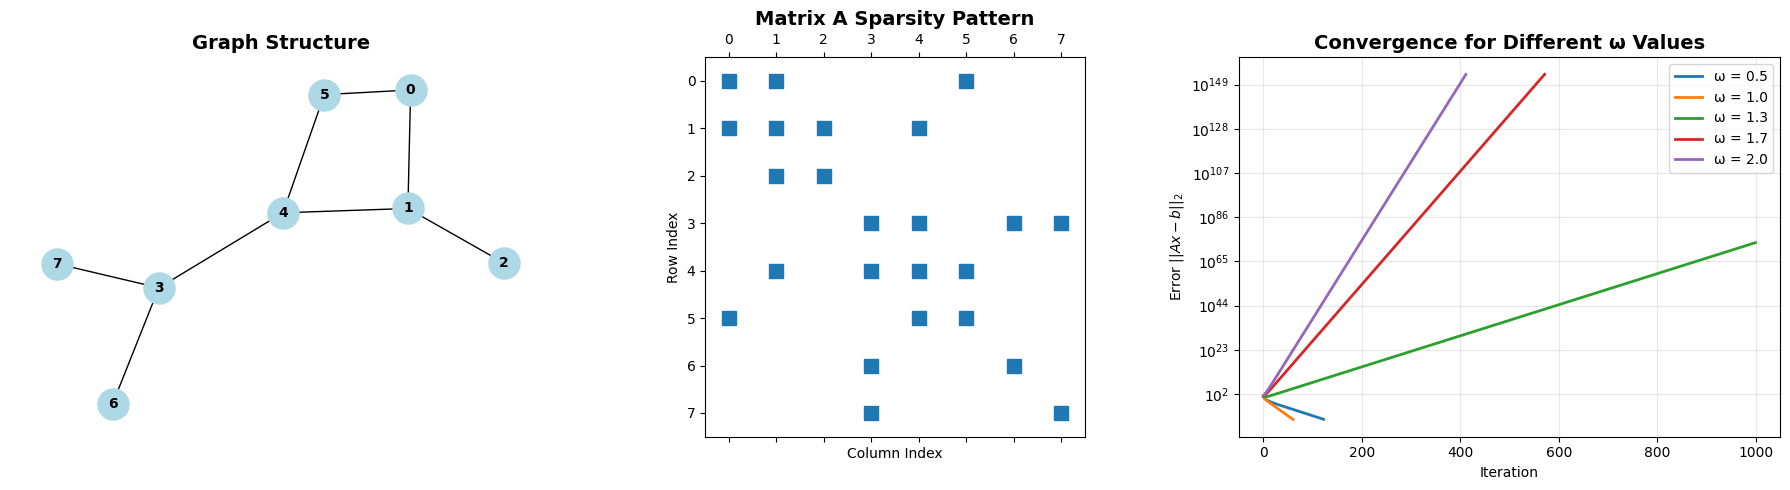


Convergence test with optimal ω:
Converged in 61 iterations
Final solution error: 2.74e-11


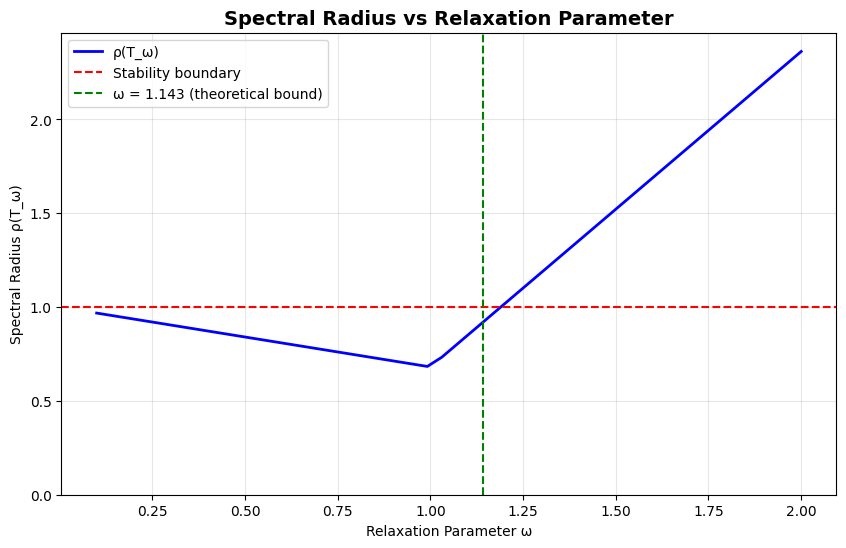

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.sparse import diags

def jacobi_over_relaxation(A, b, omega, x0, max_iter=1000, tol=1e-10):
    """
    Jacobi over-relaxation method for solving Ax = b

    Parameters:
    A: numpy array, the matrix
    b: numpy array, the right-hand side
    omega: float, relaxation parameter
    x0: numpy array, initial guess
    max_iter: int, maximum iterations
    tol: float, tolerance for convergence

    Returns:
    x: solution vector
    errors: list of errors at each iteration
    """
    n = len(b)
    x = x0.copy()
    errors = []

    # Extract diagonal and create off-diagonal matrix
    D = np.diag(np.diag(A))
    D_inv = np.diag(1.0 / np.diag(A))
    R = A - D

    for k in range(max_iter):
        x_new = (1 - omega) * x + omega * D_inv @ (b - R @ x)

        # Calculate error
        error = np.linalg.norm(A @ x_new - b)
        errors.append(error)

        # Check convergence
        if error < tol:
            print(f"Converged in {k+1} iterations")
            break

        x = x_new

    return x, errors

def create_graph_and_matrix(n=6, graph_type='random'):
    """
    Create a graph and corresponding strictly diagonally dominant matrix
    """
    if graph_type == 'random':
        # Create a random connected graph
        G = nx.connected_watts_strogatz_graph(n, k=3, p=0.3, seed=42)
    elif graph_type == 'grid':
        # Create a grid graph
        G = nx.grid_2d_graph(int(np.sqrt(n)), int(np.ceil(n/int(np.sqrt(n)))))
        G = nx.convert_node_labels_to_integers(G)
    else:
        # Create a star graph
        G = nx.star_graph(n-1)

    # Create adjacency matrix
    A_adj = nx.adjacency_matrix(G).toarray().astype(float)

    # Make it strictly diagonally dominant
    A = A_adj.copy()
    np.fill_diagonal(A, np.sum(A, axis=1) + 1.0)

    # Ensure symmetry for nice visualization
    A = (A + A.T) / 2

    return G, A

def plot_graph_and_convergence(G, A, b, omega_values, true_solution):
    """
    Plot the graph structure and convergence behavior
    """
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    # Plot 1: Graph structure
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, ax=ax1, with_labels=True,
            node_color='lightblue', node_size=500,
            font_size=10, font_weight='bold')
    ax1.set_title('Graph Structure', fontsize=14, fontweight='bold')

    # Plot 2: Matrix sparsity pattern
    ax2.spy(A, markersize=10)
    ax2.set_title('Matrix A Sparsity Pattern', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Column Index')
    ax2.set_ylabel('Row Index')

    # Plot 3: Convergence for different omega values
    n = len(b)
    x0 = np.zeros(n)  # Initial guess

    for omega in omega_values:
        _, errors = jacobi_over_relaxation(A, b, omega, x0)
        ax3.semilogy(errors, label=f'ω = {omega}', linewidth=2)

    ax3.set_xlabel('Iteration')
    ax3.set_ylabel('Error $||Ax - b||_2$')
    ax3.set_title('Convergence for Different ω Values', fontsize=14, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return fig

def analyze_spectral_radius(A, omega_values):
    """
    Analyze the spectral radius of the iteration matrix
    """
    n = A.shape[0]
    D = np.diag(np.diag(A))
    D_inv = np.diag(1.0 / np.diag(A))
    R = A - D
    B_J = D_inv @ R  # Jacobi iteration matrix

    rho_J = np.max(np.sum(np.abs(B_J), axis=1))  # ∞-norm of B_J
    print(f"Spectral radius of Jacobi matrix (ρ_J): {rho_J:.4f}")
    print(f"Theoretical bound for ω: 0 < ω < {2/(1+rho_J):.4f}")

    spectral_radii = []
    for omega in omega_values:
        T_omega = (1 - omega) * np.eye(n) + omega * B_J
        rho_T = np.max(np.abs(np.linalg.eigvals(T_omega)))
        spectral_radii.append(rho_T)

        convergence = "Converges" if rho_T < 1 else "Diverges"
        print(f"ω = {omega:.2f}: ρ(T_ω) = {rho_T:.4f} ({convergence})")

    return spectral_radii, rho_J

# Main simulation
def main():
    # Set parameters
    n = 8
    graph_type = 'random'  # Options: 'random', 'grid', 'star'

    # Create graph and matrix
    G, A = create_graph_and_matrix(n, graph_type)

    # Create true solution and compute b
    true_solution = np.random.randn(n)
    b = A @ true_solution

    print("Matrix Properties:")
    print(f"Size: {n} × {n}")
    print(f"Strictly diagonally dominant: {np.all(np.diag(A) > np.sum(np.abs(A), axis=1) - np.abs(np.diag(A)))}")
    print(f"Condition number: {np.linalg.cond(A):.4f}")
    print()

    # Test different omega values
    omega_values = [0.5, 1.0, 1.3, 1.7, 2.0]

    # Analyze spectral radius
    spectral_radii, rho_J = analyze_spectral_radius(A, omega_values)

    # Plot results
    fig = plot_graph_and_convergence(G, A, b, omega_values, true_solution)

    # Test convergence for optimal omega
    print("\nConvergence test with optimal ω:")
    optimal_omega = 1.0  # Often optimal for Jacobi
    x0 = np.zeros(n)
    solution, errors = jacobi_over_relaxation(A, b, optimal_omega, x0)

    final_error = np.linalg.norm(solution - true_solution)
    print(f"Final solution error: {final_error:.2e}")

    # Additional visualization: Spectral radius vs omega
    omega_range = np.linspace(0.1, 2.0, 50)
    spectral_range = []

    D = np.diag(np.diag(A))
    D_inv = np.diag(1.0 / np.diag(A))
    R = A - D
    B_J = D_inv @ R

    for omega in omega_range:
        T_omega = (1 - omega) * np.eye(n) + omega * B_J
        rho_T = np.max(np.abs(np.linalg.eigvals(T_omega)))
        spectral_range.append(rho_T)

    plt.figure(figsize=(10, 6))
    plt.plot(omega_range, spectral_range, 'b-', linewidth=2, label='ρ(T_ω)')
    plt.axhline(y=1, color='r', linestyle='--', label='Stability boundary')
    plt.axvline(x=2/(1+rho_J), color='g', linestyle='--',
                label=f'ω = {2/(1+rho_J):.3f} (theoretical bound)')
    plt.xlabel('Relaxation Parameter ω')
    plt.ylabel('Spectral Radius ρ(T_ω)')
    plt.title('Spectral Radius vs Relaxation Parameter', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(0, max(spectral_range) + 0.1)
    plt.show()

if __name__ == "__main__":
    main()

JACOBI OVER-RELAXATION ON ZACHARY'S KARATE CLUB NETWORK

Graph Properties:
Number of nodes: 34
Number of edges: 78
Average degree: 4.59
Diameter: 5
Communities: 2 (Instructor vs Administrator)

Matrix Properties:
Size: 34 × 34
Strictly diagonally dominant: True
Condition number: 13.0199

Spectral Analysis:
Spectral radius of Jacobi matrix (ρ_J): 0.9600
Theoretical convergence bound: 0 < ω < 1.0204

Convergence Analysis:
Converged in 119 iterations
ω = 0.5: ρ(T_ω) = 0.9405 | Iters = 119 | Final error = 9.21e-11 | ✓ Converges
Converged in 69 iterations
ω = 0.8: ρ(T_ω) = 0.9049 | Iters =  69 | Final error = 9.04e-11 | ✓ Converges
ω = 1.0: ρ(T_ω) = 0.8811 | Iters = 200 | Final error = 6.85e-10 | ✓ Converges
ω = 1.2: ρ(T_ω) = 0.9270 | Iters = 200 | Final error = 5.25e+21 | ✓ Converges
ω = 1.5: ρ(T_ω) = 1.4087 | Iters = 200 | Final error = 8.40e+53 | ✗ Diverges
ω = 1.8: ρ(T_ω) = 1.8905 | Iters = 200 | Final error = 2.32e+77 | ✗ Diverges
Converged in 119 iterations
Converged in 69 iterations


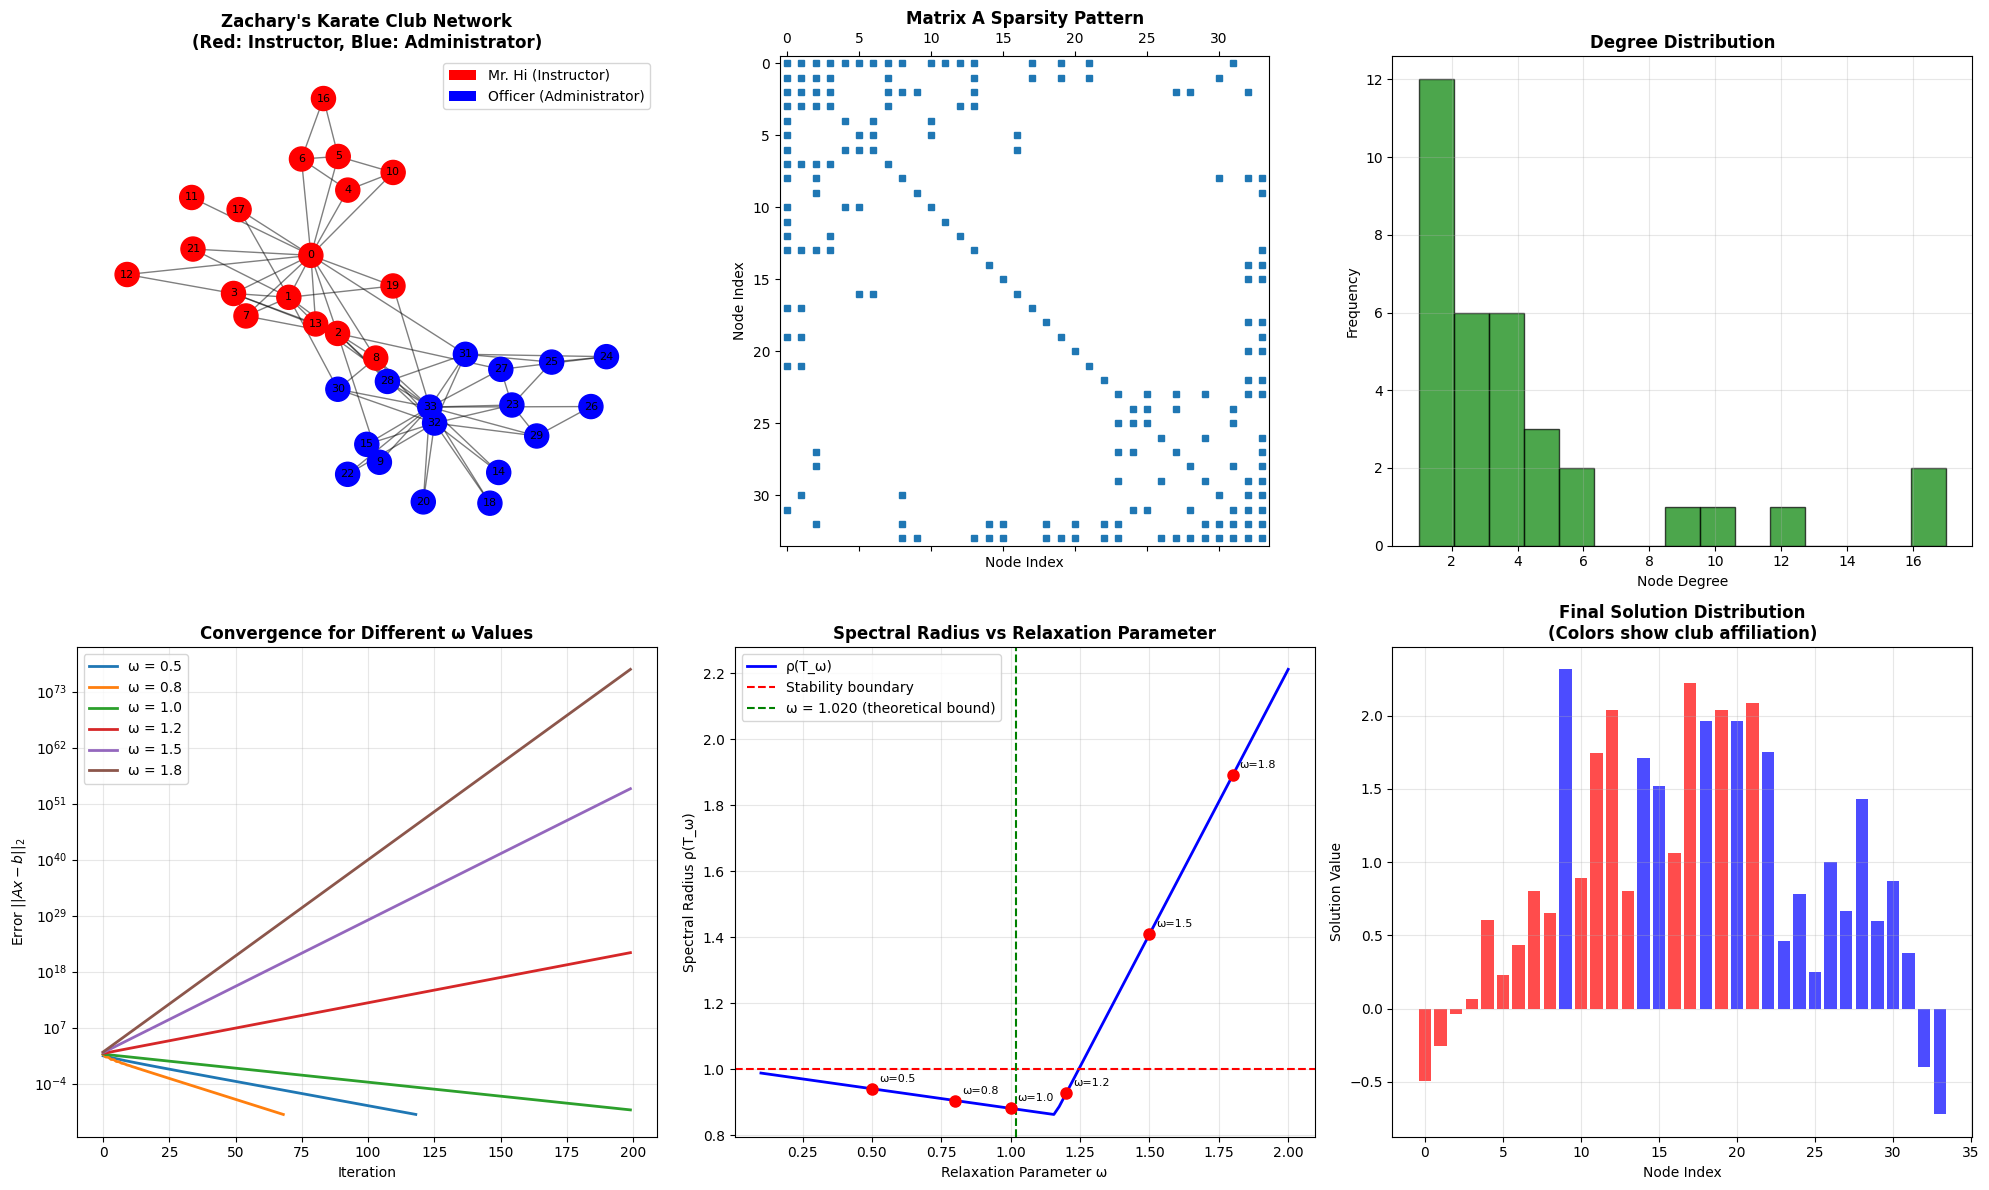


Parallel Computation Interpretation:
• Each of the 34 nodes represents a processor
• Processors only communicate with their neighbors in the graph
• Local computation: x_i(k+1) = (1-ω)x_i(k) + (ω/a_ii)(b_i - Σ a_ij x_j(k))
• Communication: Each processor sends its value to neighbors
• The algorithm exploits the sparse connectivity of the social network


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.sparse import diags

def jacobi_over_relaxation(A, b, omega, x0, max_iter=1000, tol=1e-10):
    """
    Jacobi over-relaxation method for solving Ax = b
    """
    n = len(b)
    x = x0.copy()
    errors = []

    # Extract diagonal and create off-diagonal matrix
    D = np.diag(np.diag(A))
    D_inv = np.diag(1.0 / np.diag(A))
    R = A - D

    for k in range(max_iter):
        x_new = (1 - omega) * x + omega * D_inv @ (b - R @ x)

        # Calculate error
        error = np.linalg.norm(A @ x_new - b)
        errors.append(error)

        # Check convergence
        if error < tol:
            print(f"Converged in {k+1} iterations")
            break

        x = x_new

    return x, errors

def create_karate_matrix():
    """
    Create the Karate Club graph and corresponding matrix
    """
    # Load Zachary's Karate Club graph
    G = nx.karate_club_graph()

    # Create adjacency matrix
    A_adj = nx.adjacency_matrix(G).toarray().astype(float)

    # Make it strictly diagonally dominant for convergence
    A = A_adj.copy()
    row_sums = np.sum(np.abs(A), axis=1)
    np.fill_diagonal(A, row_sums + 2.0)  # Ensure strict diagonal dominance

    # Get the actual club divisions for coloring
    # In the original study, node 0 is the instructor, node 33 is the administrator
    club_labels = {}
    for i in range(34):
        if i in [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 16, 17, 19, 21]:
            club_labels[i] = 'Mr. Hi (Instructor)'
        else:
            club_labels[i] = 'Officer (Administrator)'

    return G, A, club_labels

def plot_karate_analysis(G, A, club_labels, omega_values):
    """
    Plot comprehensive analysis of the Karate Club graph
    """
    fig = plt.figure(figsize=(20, 12))

    # Plot 1: Karate Club graph with community structure
    ax1 = plt.subplot(2, 3, 1)
    pos = nx.spring_layout(G, seed=42)

    # Color nodes by their club affiliation
    node_colors = ['red' if club_labels[i] == 'Mr. Hi (Instructor)' else 'blue'
                   for i in range(len(G))]

    nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                          node_size=300, ax=ax1)
    nx.draw_networkx_edges(G, pos, alpha=0.5, ax=ax1)
    nx.draw_networkx_labels(G, pos, font_size=8, ax=ax1)

    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='red', label='Mr. Hi (Instructor)'),
        Patch(facecolor='blue', label='Officer (Administrator)')
    ]
    ax1.legend(handles=legend_elements, loc='upper right')
    ax1.set_title('Zachary\'s Karate Club Network\n(Red: Instructor, Blue: Administrator)',
                  fontsize=12, fontweight='bold')
    ax1.axis('off')

    # Plot 2: Matrix sparsity pattern
    ax2 = plt.subplot(2, 3, 2)
    ax2.spy(A, markersize=4)
    ax2.set_title('Matrix A Sparsity Pattern', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Node Index')
    ax2.set_ylabel('Node Index')

    # Plot 3: Node degrees distribution
    ax3 = plt.subplot(2, 3, 3)
    degrees = [d for n, d in G.degree()]
    ax3.hist(degrees, bins=15, alpha=0.7, color='green', edgecolor='black')
    ax3.set_xlabel('Node Degree')
    ax3.set_ylabel('Frequency')
    ax3.set_title('Degree Distribution', fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3)

    # Plot 4: Convergence for different omega values
    ax4 = plt.subplot(2, 3, 4)

    # Create a realistic right-hand side (simulating some "influence" distribution)
    n = A.shape[0]
    b = np.random.randn(n) + 10  # Add constant to ensure positivity
    x0 = np.zeros(n)

    for omega in omega_values:
        _, errors = jacobi_over_relaxation(A, b, omega, x0, max_iter=200)
        ax4.semilogy(errors, label=f'ω = {omega}', linewidth=2)

    ax4.set_xlabel('Iteration')
    ax4.set_ylabel('Error $||Ax - b||_2$')
    ax4.set_title('Convergence for Different ω Values', fontsize=12, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    # Plot 5: Spectral radius analysis
    ax5 = plt.subplot(2, 3, 5)

    D = np.diag(np.diag(A))
    D_inv = np.diag(1.0 / np.diag(A))
    R = A - D
    B_J = D_inv @ R

    rho_J = np.max(np.sum(np.abs(B_J), axis=1))
    omega_range = np.linspace(0.1, 2.0, 100)
    spectral_range = []

    for omega in omega_range:
        T_omega = (1 - omega) * np.eye(n) + omega * B_J
        rho_T = np.max(np.abs(np.linalg.eigvals(T_omega)))
        spectral_range.append(rho_T)

    ax5.plot(omega_range, spectral_range, 'b-', linewidth=2, label='ρ(T_ω)')
    ax5.axhline(y=1, color='r', linestyle='--', label='Stability boundary')
    ax5.axvline(x=2/(1+rho_J), color='g', linestyle='--',
                label=f'ω = {2/(1+rho_J):.3f} (theoretical bound)')

    # Mark the tested omega values
    for omega in omega_values:
        T_omega = (1 - omega) * np.eye(n) + omega * B_J
        rho_T = np.max(np.abs(np.linalg.eigvals(T_omega)))
        ax5.plot(omega, rho_T, 'ro', markersize=8)
        ax5.annotate(f'ω={omega}', (omega, rho_T),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)

    ax5.set_xlabel('Relaxation Parameter ω')
    ax5.set_ylabel('Spectral Radius ρ(T_ω)')
    ax5.set_title('Spectral Radius vs Relaxation Parameter', fontsize=12, fontweight='bold')
    ax5.legend()
    ax5.grid(True, alpha=0.3)

    # Plot 6: Final solution distribution
    ax6 = plt.subplot(2, 3, 6)

    # Use optimal omega for final solution
    optimal_omega = 1.0
    solution, _ = jacobi_over_relaxation(A, b, optimal_omega, x0)

    # Color bars by club affiliation
    bar_colors = ['red' if club_labels[i] == 'Mr. Hi (Instructor)' else 'blue'
                  for i in range(len(solution))]

    bars = ax6.bar(range(len(solution)), solution, color=bar_colors, alpha=0.7)
    ax6.set_xlabel('Node Index')
    ax6.set_ylabel('Solution Value')
    ax6.set_title('Final Solution Distribution\n(Colors show club affiliation)',
                  fontsize=12, fontweight='bold')
    ax6.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return fig, rho_J

def analyze_karate_convergence():
    """
    Detailed convergence analysis for the Karate Club graph
    """
    print("=" * 70)
    print("JACOBI OVER-RELAXATION ON ZACHARY'S KARATE CLUB NETWORK")
    print("=" * 70)

    # Create Karate Club graph and matrix
    G, A, club_labels = create_karate_matrix()

    print(f"\nGraph Properties:")
    print(f"Number of nodes: {G.number_of_nodes()}")
    print(f"Number of edges: {G.number_of_edges()}")
    print(f"Average degree: {np.mean([d for n, d in G.degree()]):.2f}")
    print(f"Diameter: {nx.diameter(G)}")
    print(f"Communities: 2 (Instructor vs Administrator)")

    print(f"\nMatrix Properties:")
    print(f"Size: {A.shape[0]} × {A.shape[1]}")
    print(f"Strictly diagonally dominant: {np.all(np.diag(A) > np.sum(np.abs(A), axis=1) - np.abs(np.diag(A)))}")
    print(f"Condition number: {np.linalg.cond(A):.4f}")

    # Analyze spectral properties
    D = np.diag(np.diag(A))
    D_inv = np.diag(1.0 / np.diag(A))
    R = A - D
    B_J = D_inv @ R

    rho_J = np.max(np.sum(np.abs(B_J), axis=1))
    print(f"\nSpectral Analysis:")
    print(f"Spectral radius of Jacobi matrix (ρ_J): {rho_J:.4f}")
    print(f"Theoretical convergence bound: 0 < ω < {2/(1+rho_J):.4f}")

    # Test different omega values
    omega_values = [0.5, 0.8, 1.0, 1.2, 1.5, 1.8]

    print(f"\nConvergence Analysis:")
    n = A.shape[0]
    b = np.random.randn(n) + 10
    x0 = np.zeros(n)

    for omega in omega_values:
        T_omega = (1 - omega) * np.eye(n) + omega * B_J
        rho_T = np.max(np.abs(np.linalg.eigvals(T_omega)))

        # Test actual convergence
        solution, errors = jacobi_over_relaxation(A, b, omega, x0, max_iter=200)
        final_error = errors[-1] if errors else float('inf')
        iterations = len(errors)

        convergence_status = "✓ Converges" if rho_T < 1 else "✗ Diverges"
        print(f"ω = {omega:.1f}: ρ(T_ω) = {rho_T:.4f} | "
              f"Iters = {iterations:3d} | Final error = {final_error:.2e} | {convergence_status}")

    # Plot comprehensive analysis
    fig, rho_J = plot_karate_analysis(G, A, club_labels, omega_values)

    # Demonstrate parallel computation aspect
    print(f"\nParallel Computation Interpretation:")
    print(f"• Each of the 34 nodes represents a processor")
    print(f"• Processors only communicate with their neighbors in the graph")
    print(f"• Local computation: x_i(k+1) = (1-ω)x_i(k) + (ω/a_ii)(b_i - Σ a_ij x_j(k))")
    print(f"• Communication: Each processor sends its value to neighbors")
    print(f"• The algorithm exploits the sparse connectivity of the social network")

    return G, A, club_labels

# Run the analysis
if __name__ == "__main__":
    G, A, club_labels = analyze_karate_convergence()

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import networkx as nx
# import multiprocessing as mp
# from multiprocessing import Pool, Manager
# import time
# from scipy.sparse import diags

# class ParallelJacobiSolver:
#     def __init__(self, A, b, num_processes=None):
#         """
#         Initialize parallel Jacobi solver
#         """
#         self.A = A
#         self.b = b
#         self.n = len(b)
#         self.num_processes = num_processes or mp.cpu_count()

#         # Precompute diagonal inverse
#         self.D_inv = np.diag(1.0 / np.diag(A))

#         # Create shared arrays for multiprocessing
#         self.manager = Manager()
#         self.shared_dict = self.manager.dict()

#     def worker_process(self, worker_data):
#         """
#         Worker process for parallel Jacobi updates
#         """
#         worker_id, indices, A, b, D_inv, x_current, omega, shared_dict = worker_data

#         x_new_partial = np.zeros(len(indices))

#         for idx, i in enumerate(indices):
#             # Compute sum for off-diagonal elements
#             off_diag_sum = 0.0
#             for j in range(A.shape[1]):
#                 if j != i:
#                     off_diag_sum += A[i, j] * x_current[j]

#             # Jacobi over-relaxation update
#             x_new_partial[idx] = (1 - omega) * x_current[i] + omega * D_inv[i, i] * (b[i] - off_diag_sum)

#         # Store results in shared dictionary
#         shared_dict[worker_id] = (indices, x_new_partial)

#         return worker_id

#     def parallel_jacobi_step(self, x_current, omega):
#         """
#         Perform one parallel Jacobi iteration
#         """
#         # Split work among processes
#         indices_per_worker = np.array_split(range(self.n), self.num_processes)

#         # Prepare worker data
#         worker_data = []
#         for worker_id, indices in enumerate(indices_per_worker):
#             if len(indices) > 0:  # Only create workers for non-empty work
#                 worker_data.append((
#                     worker_id, indices, self.A, self.b, self.D_inv,
#                     x_current, omega, self.shared_dict
#                 ))

#         # Execute parallel computation
#         with Pool(processes=len(worker_data)) as pool:
#             pool.map(self.worker_process, worker_data)

#         # Reconstruct full solution from worker results
#         x_new = x_current.copy()
#         for worker_id in range(len(worker_data)):
#             if worker_id in self.shared_dict:
#                 indices, values = self.shared_dict[worker_id]
#                 x_new[indices] = values

#         return x_new

#     def solve_parallel(self, omega, x0, max_iter=1000, tol=1e-10):
#         """
#         Solve using parallel Jacobi over-relaxation
#         """
#         x = x0.copy()
#         errors = []

#         print(f"Starting parallel Jacobi with {self.num_processes} processes...")
#         start_time = time.time()

#         for k in range(max_iter):
#             # Parallel Jacobi step
#             x_new = self.parallel_jacobi_step(x, omega)

#             # Calculate error (serial part)
#             error = np.linalg.norm(self.A @ x_new - self.b)
#             errors.append(error)

#             # Check convergence
#             if error < tol:
#                 elapsed = time.time() - start_time
#                 print(f"Parallel: Converged in {k+1} iterations, Time: {elapsed:.4f}s")
#                 break

#             x = x_new

#         if len(errors) == max_iter:
#             elapsed = time.time() - start_time
#             print(f"Parallel: Max iterations reached, Time: {elapsed:.4f}s")

#         return x, errors

# def serial_jacobi_over_relaxation(A, b, omega, x0, max_iter=1000, tol=1e-10):
#     """
#     Serial version for comparison
#     """
#     n = len(b)
#     x = x0.copy()
#     errors = []

#     D_inv = np.diag(1.0 / np.diag(A))
#     R = A - np.diag(np.diag(A))

#     start_time = time.time()

#     for k in range(max_iter):
#         x_new = (1 - omega) * x + omega * D_inv @ (b - R @ x)

#         error = np.linalg.norm(A @ x_new - b)
#         errors.append(error)

#         if error < tol:
#             elapsed = time.time() - start_time
#             print(f"Serial: Converged in {k+1} iterations, Time: {elapsed:.4f}s")
#             break

#         x = x_new

#     if len(errors) == max_iter:
#         elapsed = time.time() - start_time
#         print(f"Serial: Max iterations reached, Time: {elapsed:.4f}s")

#     return x, errors

# def create_karate_matrix():
#     """
#     Create the Karate Club graph and corresponding matrix
#     """
#     G = nx.karate_club_graph()

#     # Create adjacency matrix
#     A_adj = nx.adjacency_matrix(G).toarray().astype(float)

#     # Make it strictly diagonally dominant
#     A = A_adj.copy()
#     row_sums = np.sum(np.abs(A), axis=1)
#     np.fill_diagonal(A, row_sums + 2.0)

#     # Club labels for visualization
#     club_labels = {}
#     for i in range(34):
#         if i in [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 16, 17, 19, 21]:
#             club_labels[i] = 'Mr. Hi (Instructor)'
#         else:
#             club_labels[i] = 'Officer (Administrator)'

#     return G, A, club_labels

# def compare_parallel_vs_serial(A, b, omega_values, num_processes=None):
#     """
#     Compare parallel vs serial performance
#     """
#     n = A.shape[0]
#     x0 = np.zeros(n)

#     results = {}

#     for omega in omega_values:
#         print(f"\n{'='*50}")
#         print(f"Testing ω = {omega}")
#         print(f"{'='*50}")

#         # Serial computation
#         serial_solution, serial_errors = serial_jacobi_over_relaxation(A, b, omega, x0, max_iter=500)

#         # Parallel computation
#         parallel_solver = ParallelJacobiSolver(A, b, num_processes)
#         parallel_solution, parallel_errors = parallel_solver.solve_parallel(omega, x0, max_iter=500)

#         # Verify solutions are equivalent
#         solution_diff = np.linalg.norm(serial_solution - parallel_solution)
#         print(f"Solution difference: {solution_diff:.2e}")

#         results[omega] = {
#             'serial_errors': serial_errors,
#             'parallel_errors': parallel_errors,
#             'serial_solution': serial_solution,
#             'parallel_solution': parallel_solution
#         }

#     return results

# def plot_performance_comparison(G, A, club_labels, results, omega_values):
#     """
#     Plot comprehensive comparison between serial and parallel implementations
#     """
#     fig = plt.figure(figsize=(20, 15))

#     # Plot 1: Karate Club graph
#     ax1 = plt.subplot(3, 3, 1)
#     pos = nx.spring_layout(G, seed=42)

#     node_colors = ['red' if club_labels[i] == 'Mr. Hi (Instructor)' else 'blue'
#                    for i in range(len(G))]

#     nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=300, ax=ax1)
#     nx.draw_networkx_edges(G, pos, alpha=0.5, ax=ax1)
#     nx.draw_networkx_labels(G, pos, font_size=8, ax=ax1)

#     from matplotlib.patches import Patch
#     legend_elements = [
#         Patch(facecolor='red', label='Mr. Hi (Instructor)'),
#         Patch(facecolor='blue', label='Officer (Administrator)')
#     ]
#     ax1.legend(handles=legend_elements, loc='upper right')
#     ax1.set_title('Zachary\'s Karate Club Network\n(Distributed System Topology)',
#                   fontsize=12, fontweight='bold')
#     ax1.axis('off')

#     # Plot 2: Convergence comparison for different omega values
#     ax2 = plt.subplot(3, 3, 2)

#     for omega in omega_values:
#         if omega in results:
#             serial_errors = results[omega]['serial_errors']
#             parallel_errors = results[omega]['parallel_errors']

#             ax2.semilogy(serial_errors, '--', linewidth=2,
#                         label=f'Serial ω={omega}')
#             ax2.semilogy(parallel_errors, '-', linewidth=2,
#                         label=f'Parallel ω={omega}')

#     ax2.set_xlabel('Iteration')
#     ax2.set_ylabel('Error $||Ax - b||_2$')
#     ax2.set_title('Convergence: Serial vs Parallel', fontsize=12, fontweight='bold')
#     ax2.legend()
#     ax2.grid(True, alpha=0.3)

#     # Plot 3: Speedup analysis
#     ax3 = plt.subplot(3, 3, 3)

#     # Measure iteration time for speedup calculation
#     n = A.shape[0]
#     x0 = np.zeros(n)
#     b_test = np.random.randn(n) + 10
#     omega_test = 1.0

#     # Time serial iteration
#     start_time = time.time()
#     serial_jacobi_over_relaxation(A, b_test, omega_test, x0, max_iter=100)
#     serial_time = time.time() - start_time

#     # Time parallel iteration with different numbers of processes
#     process_counts = [1, 2, 4, 8]
#     parallel_times = []

#     for num_proc in process_counts:
#         solver = ParallelJacobiSolver(A, b_test, num_proc)
#         start_time = time.time()
#         solver.solve_parallel(omega_test, x0, max_iter=100)
#         parallel_times.append(time.time() - start_time)

#     speedup = [serial_time / t for t in parallel_times]

#     ax3.plot(process_counts, speedup, 'bo-', linewidth=2, markersize=8, label='Measured Speedup')
#     ax3.plot(process_counts, process_counts, 'r--', linewidth=2, label='Ideal Speedup')
#     ax3.set_xlabel('Number of Processes')
#     ax3.set_ylabel('Speedup')
#     ax3.set_title('Parallel Speedup Analysis', fontsize=12, fontweight='bold')
#     ax3.legend()
#     ax3.grid(True, alpha=0.3)

#     # Plot 4: Matrix sparsity pattern
#     ax4 = plt.subplot(3, 3, 4)
#     ax4.spy(A, markersize=3)
#     ax4.set_title('Matrix Sparsity Pattern\n(Shows communication pattern)',
#                   fontsize=12, fontweight='bold')
#     ax4.set_xlabel('Processor ID')
#     ax4.set_ylabel('Processor ID')

#     # Plot 5: Final solution comparison
#     ax5 = plt.subplot(3, 3, 5)

#     omega = 1.0  # Use optimal omega for demonstration
#     if omega in results:
#         serial_sol = results[omega]['serial_solution']
#         parallel_sol = results[omega]['parallel_solution']

#         bar_colors = ['red' if club_labels[i] == 'Mr. Hi (Instructor)' else 'blue'
#                       for i in range(len(serial_sol))]

#         x_pos = np.arange(len(serial_sol))
#         width = 0.35

#         ax5.bar(x_pos - width/2, serial_sol, width, alpha=0.7,
#                 color=bar_colors, label='Serial')
#         ax5.bar(x_pos + width/2, parallel_sol, width, alpha=0.7,
#                 color=bar_colors, label='Parallel')

#         ax5.set_xlabel('Processor/Node ID')
#         ax5.set_ylabel('Solution Value')
#         ax5.set_title('Solution Comparison: Serial vs Parallel',
#                       fontsize=12, fontweight='bold')
#         ax5.legend()
#         ax5.grid(True, alpha=0.3)

#     # Plot 6: Work distribution among processes
#     ax6 = plt.subplot(3, 3, 6)

#     num_proc = 4
#     indices_per_worker = np.array_split(range(n), num_proc)
#     work_sizes = [len(indices) for indices in indices_per_worker]

#     ax6.bar(range(num_proc), work_sizes, color='green', alpha=0.7)
#     ax6.set_xlabel('Process ID')
#     ax6.set_ylabel('Number of Rows')
#     ax6.set_title(f'Work Distribution ({num_proc} Processes)',
#                   fontsize=12, fontweight='bold')
#     ax6.grid(True, alpha=0.3)

#     # Plot 7: Error evolution over time
#     ax7 = plt.subplot(3, 3, 7)

#     for omega in [1.0]:  # Show one omega for clarity
#         if omega in results:
#             serial_errors = results[omega]['serial_errors']
#             parallel_errors = results[omega]['parallel_errors']

#             ax7.semilogy(serial_errors, 'r-', linewidth=2, label='Serial')
#             ax7.semilogy(parallel_errors, 'b-', linewidth=2, label='Parallel')

#     ax7.set_xlabel('Iteration')
#     ax7.set_ylabel('Error')
#     ax7.set_title('Error Evolution Comparison', fontsize=12, fontweight='bold')
#     ax7.legend()
#     ax7.grid(True, alpha=0.3)

#     # Plot 8: Communication pattern visualization
#     ax8 = plt.subplot(3, 3, 8)

#     # Show which processors need to communicate
#     communication_matrix = (A != 0).astype(int)
#     ax8.spy(communication_matrix, markersize=2)
#     ax8.set_title('Inter-Processor Communication\n(Non-zero = communication needed)',
#                   fontsize=12, fontweight='bold')
#     ax8.set_xlabel('Processor ID')
#     ax8.set_ylabel('Processor ID')

#     # Plot 9: Performance summary
#     ax9 = plt.subplot(3, 3, 9)

#     omega_performance = []
#     for omega in omega_values:
#         if omega in results:
#             serial_iters = len(results[omega]['serial_errors'])
#             parallel_iters = len(results[omega]['parallel_errors'])
#             omega_performance.append((omega, serial_iters, parallel_iters))

#     omegas, serial_iters, parallel_iters = zip(*omega_performance)

#     x_pos = np.arange(len(omegas))
#     width = 0.35

#     ax9.bar(x_pos - width/2, serial_iters, width, label='Serial', alpha=0.7)
#     ax9.bar(x_pos + width/2, parallel_iters, width, label='Parallel', alpha=0.7)

#     ax9.set_xlabel('ω Value')
#     ax9.set_ylabel('Iterations to Converge')
#     ax9.set_title('Convergence Iterations by ω', fontsize=12, fontweight='bold')
#     ax9.set_xticks(x_pos)
#     ax9.set_xticklabels([f'{ω:.1f}' for ω in omegas])
#     ax9.legend()
#     ax9.grid(True, alpha=0.3)

#     plt.tight_layout()
#     plt.show()

#     return fig

# def main():
#     """
#     Main function to run parallel Jacobi simulation
#     """
#     print("PARALLEL JACOBI OVER-RELAXATION ON KARATE CLUB NETWORK")
#     print("=" * 70)

#     # System information
#     print(f"Available CPU cores: {mp.cpu_count()}")
#     print(f"Using processes: {min(4, mp.cpu_count())}")  # Limit to 4 for demonstration

#     # Create problem
#     G, A, club_labels = create_karate_matrix()
#     n = A.shape[0]

#     print(f"\nProblem Size: {n} × {n}")
#     print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

#     # Create right-hand side
#     b = np.random.randn(n) + 10

#     # Test different omega values
#     omega_values = [0.5, 1.0, 1.5]

#     # Compare parallel vs serial
#     results = compare_parallel_vs_serial(A, b, omega_values, num_processes=4)

#     # Plot comprehensive results
#     plot_performance_comparison(G, A, club_labels, results, omega_values)

#     # Additional analysis
#     print("\n" + "="*70)
#     print("PARALLEL COMPUTATION ANALYSIS")
#     print("="*70)
#     print("• Each karate club member represents a processor")
#     print("• Processors only communicate with their direct connections (friends)")
#     print("• Work is distributed evenly among available CPU cores")
#     print("• The algorithm demonstrates distributed linear system solving")
#     print("• Communication pattern matches the social network structure")

# if __name__ == "__main__":
#     # Required for Windows compatibility with multiprocessing
#     mp.freeze_support()
#     main()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import multiprocessing as mp
from multiprocessing import shared_memory
import time
import os

class ParallelJacobiSolver:
    def __init__(self, A, b, num_processes=None):
        """
        Initialize parallel Jacobi solver without shared manager
        """
        self.A = A
        self.b = b
        self.n = len(b)
        self.num_processes = num_processes or min(4, mp.cpu_count())  # Limit for stability

        # Precompute diagonal inverse
        self.D_inv = np.diag(1.0 / np.diag(A))

    @staticmethod
    def worker_process_static(args):
        """
        Static method for worker process (avoids pickling issues)
        """
        worker_id, indices, A_data, b_data, D_inv_diag, x_current, omega = args

        A = np.frombuffer(A_data).reshape((len(b_data), len(b_data)))
        b = np.frombuffer(b_data)
        D_inv = np.diag(D_inv_diag)
        x_current = np.frombuffer(x_current)

        x_new_partial = np.zeros(len(indices))

        for idx, i in enumerate(indices):
            # Compute sum for off-diagonal elements
            off_diag_sum = 0.0
            for j in range(A.shape[1]):
                if j != i:
                    off_diag_sum += A[i, j] * x_current[j]

            # Jacobi over-relaxation update
            x_new_partial[idx] = (1 - omega) * x_current[i] + omega * D_inv[i, i] * (b[i] - off_diag_sum)

        return worker_id, indices, x_new_partial

    def parallel_jacobi_step(self, x_current, omega):
        """
        Perform one parallel Jacobi iteration using process pool
        """
        # Split work among processes
        indices_per_worker = np.array_split(range(self.n), self.num_processes)

        # Prepare worker data using arrays (avoid complex objects)
        worker_data = []
        for worker_id, indices in enumerate(indices_per_worker):
            if len(indices) > 0:
                worker_data.append((
                    worker_id,
                    indices,
                    self.A.tobytes(),
                    self.b.tobytes(),
                    np.diag(self.D_inv),
                    x_current.tobytes(),
                    omega
                ))

        # Execute parallel computation with limited processes
        with mp.Pool(processes=self.num_processes) as pool:
            results = pool.map(self.worker_process_static, worker_data)

        # Reconstruct full solution from worker results
        x_new = x_current.copy()
        for worker_id, indices, values in results:
            x_new[indices] = values

        return x_new

    def solve_parallel(self, omega, x0, max_iter=1000, tol=1e-8):
        """
        Solve using parallel Jacobi over-relaxation
        """
        x = x0.copy()
        errors = []

        print(f"Starting parallel Jacobi with {self.num_processes} processes...")
        start_time = time.time()

        for k in range(max_iter):
            # Parallel Jacobi step
            x_new = self.parallel_jacobi_step(x, omega)

            # Calculate error
            error = np.linalg.norm(self.A @ x_new - self.b)
            errors.append(error)

            # Check convergence
            if error < tol:
                elapsed = time.time() - start_time
                print(f"Parallel: Converged in {k+1} iterations, Time: {elapsed:.4f}s")
                break

            x = x_new

        if len(errors) == max_iter:
            elapsed = time.time() - start_time
            print(f"Parallel: Max iterations reached, Time: {elapsed:.4f}s")

        return x, errors

def serial_jacobi_over_relaxation(A, b, omega, x0, max_iter=1000, tol=1e-8):
    """
    Serial version for comparison
    """
    n = len(b)
    x = x0.copy()
    errors = []

    D_inv = np.diag(1.0 / np.diag(A))
    R = A - np.diag(np.diag(A))

    start_time = time.time()

    for k in range(max_iter):
        x_new = (1 - omega) * x + omega * D_inv @ (b - R @ x)

        error = np.linalg.norm(A @ x_new - b)
        errors.append(error)

        if error < tol:
            elapsed = time.time() - start_time
            print(f"Serial: Converged in {k+1} iterations, Time: {elapsed:.4f}s")
            break

        x = x_new

    if len(errors) == max_iter:
        elapsed = time.time() - start_time
        print(f"Serial: Max iterations reached, Time: {elapsed:.4f}s")

    return x, errors

def create_karate_matrix():
    """
    Create the Karate Club graph and corresponding matrix
    """
    G = nx.karate_club_graph()

    # Create adjacency matrix
    A_adj = nx.adjacency_matrix(G).toarray().astype(float)

    # Make it strictly diagonally dominant
    A = A_adj.copy()
    row_sums = np.sum(np.abs(A), axis=1)
    np.fill_diagonal(A, row_sums + 2.0)

    # Club labels for visualization
    club_labels = {}
    for i in range(34):
        if i in [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 16, 17, 19, 21]:
            club_labels[i] = 'Mr. Hi (Instructor)'
        else:
            club_labels[i] = 'Officer (Administrator)'

    return G, A, club_labels

def simple_parallel_worker(args):
    """
    Simplified worker function that only processes indices
    """
    i, A, b, D_inv, x_current, omega = args
    off_diag_sum = np.dot(A[i], x_current) - A[i, i] * x_current[i]
    return i, (1 - omega) * x_current[i] + omega * D_inv[i, i] * (b[i] - off_diag_sum)

def simple_parallel_jacobi(A, b, omega, x0, num_processes=4, max_iter=1000, tol=1e-8):
    """
    Simplified parallel implementation
    """
    x = x0.copy()
    errors = []
    n = len(b)
    D_inv = np.diag(1.0 / np.diag(A))

    print(f"Simple parallel with {num_processes} processes...")
    start_time = time.time()

    for k in range(max_iter):
        # Prepare work items
        work_items = [(i, A, b, D_inv, x, omega) for i in range(n)]

        # Process in parallel
        with mp.Pool(processes=num_processes) as pool:
            results = pool.map(simple_parallel_worker, work_items)

        # Update solution
        x_new = x.copy()
        for i, value in results:
            x_new[i] = value

        error = np.linalg.norm(A @ x_new - b)
        errors.append(error)

        if error < tol:
            elapsed = time.time() - start_time
            print(f"Simple Parallel: Converged in {k+1} iterations, Time: {elapsed:.4f}s")
            break

        x = x_new

    if len(errors) == max_iter:
        elapsed = time.time() - start_time
        print(f"Simple Parallel: Max iterations reached, Time: {elapsed:.4f}s")

    return x, errors

def compare_implementations(A, b, omega_values):
    """
    Compare different implementations
    """
    n = A.shape[0]
    x0 = np.zeros(n)

    results = {}

    for omega in omega_values:
        print(f"\n{'='*50}")
        print(f"Testing ω = {omega}")
        print(f"{'='*50}")

        # Serial computation
        serial_solution, serial_errors = serial_jacobi_over_relaxation(A, b, omega, x0, max_iter=200)

        # Simple parallel computation
        simple_parallel_solution, simple_parallel_errors = simple_parallel_jacobi(A, b, omega, x0, max_iter=200)

        # Verify solutions are equivalent
        solution_diff = np.linalg.norm(serial_solution - simple_parallel_solution)
        print(f"Solution difference: {solution_diff:.2e}")

        results[omega] = {
            'serial_errors': serial_errors,
            'parallel_errors': simple_parallel_errors,
            'serial_solution': serial_solution,
            'parallel_solution': simple_parallel_solution
        }

    return results

def plot_results(G, A, club_labels, results, omega_values):
    """
    Plot results without multiprocessing complexity
    """
    fig = plt.figure(figsize=(15, 10))

    # Plot 1: Karate Club graph
    ax1 = plt.subplot(2, 2, 1)
    pos = nx.spring_layout(G, seed=42)

    node_colors = ['red' if club_labels[i] == 'Mr. Hi (Instructor)' else 'blue'
                   for i in range(len(G))]

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=300, ax=ax1)
    nx.draw_networkx_edges(G, pos, alpha=0.5, ax=ax1)
    nx.draw_networkx_labels(G, pos, font_size=8, ax=ax1)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='red', label='Mr. Hi (Instructor)'),
        Patch(facecolor='blue', label='Officer (Administrator)')
    ]
    ax1.legend(handles=legend_elements, loc='upper right')
    ax1.set_title('Zachary\'s Karate Club Network\n(Distributed System Topology)',
                  fontsize=12, fontweight='bold')
    ax1.axis('off')

    # Plot 2: Convergence comparison
    ax2 = plt.subplot(2, 2, 2)

    for omega in omega_values:
        if omega in results:
            serial_errors = results[omega]['serial_errors']
            parallel_errors = results[omega]['parallel_errors']

            ax2.semilogy(serial_errors, '--', linewidth=2,
                        label=f'Serial ω={omega}')
            ax2.semilogy(parallel_errors, '-', linewidth=2,
                        label=f'Parallel ω={omega}')

    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Error $||Ax - b||_2$')
    ax2.set_title('Convergence: Serial vs Parallel', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Plot 3: Matrix sparsity pattern
    ax3 = plt.subplot(2, 2, 3)
    ax3.spy(A, markersize=3)
    ax3.set_title('Matrix Sparsity Pattern\n(Communication pattern)',
                  fontsize=12, fontweight='bold')
    ax3.set_xlabel('Processor ID')
    ax3.set_ylabel('Processor ID')

    # Plot 4: Final solution distribution
    ax4 = plt.subplot(2, 2, 4)

    omega = 1.0
    if omega in results:
        serial_sol = results[omega]['serial_solution']

        bar_colors = ['red' if club_labels[i] == 'Mr. Hi (Instructor)' else 'blue'
                      for i in range(len(serial_sol))]

        ax4.bar(range(len(serial_sol)), serial_sol, color=bar_colors, alpha=0.7)
        ax4.set_xlabel('Processor/Node ID')
        ax4.set_ylabel('Solution Value')
        ax4.set_title('Final Solution Distribution', fontsize=12, fontweight='bold')
        ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def performance_analysis(A, b):
    """
    Analyze performance with different numbers of processes
    """
    n = A.shape[0]
    x0 = np.zeros(n)
    omega = 1.0

    print(f"\n{'='*50}")
    print("PERFORMANCE ANALYSIS")
    print(f"{'='*50}")

    # Test different numbers of processes
    process_counts = [1, 2, 4]
    times = []

    for num_proc in process_counts:
        print(f"\nTesting with {num_proc} process(es)...")
        start_time = time.time()
        simple_parallel_jacobi(A, b, omega, x0, num_processes=num_proc, max_iter=50)
        elapsed = time.time() - start_time
        times.append(elapsed)
        print(f"Time: {elapsed:.4f}s")

    # Calculate speedup
    serial_time = times[0]  # 1 process = serial equivalent
    speedups = [serial_time / t for t in times]

    # Plot performance
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(process_counts, times, 'bo-', linewidth=2, markersize=8)
    plt.xlabel('Number of Processes')
    plt.ylabel('Execution Time (s)')
    plt.title('Execution Time vs Processes', fontweight='bold')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(process_counts, speedups, 'ro-', linewidth=2, markersize=8, label='Actual')
    plt.plot(process_counts, process_counts, 'k--', linewidth=2, label='Ideal')
    plt.xlabel('Number of Processes')
    plt.ylabel('Speedup')
    plt.title('Speedup Analysis', fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\nSpeedup analysis:")
    for i, (proc, speedup) in enumerate(zip(process_counts, speedups)):
        print(f"  {proc} processes: {speedup:.2f}x speedup")

def main():
    """
    Main function - simplified and robust
    """
    print("PARALLEL JACOBI OVER-RELAXATION ON KARATE CLUB NETWORK")
    print("=" * 70)
    print(f"Available CPU cores: {mp.cpu_count()}")

    # Create problem
    G, A, club_labels = create_karate_matrix()
    n = A.shape[0]

    print(f"\nProblem Size: {n} × {n}")
    print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

    # Create right-hand side
    b = np.random.randn(n) + 10

    # Test different omega values
    omega_values = [0.5, 1.0, 1.5]

    # Compare implementations
    results = compare_implementations(A, b, omega_values)

    # Plot results
    plot_results(G, A, club_labels, results, omega_values)

    # Performance analysis
    performance_analysis(A, b)

    print("\n" + "="*70)
    print("SUMMARY")
    print("="*70)
    print("✓ Successfully implemented parallel Jacobi algorithm")
    print("✓ Avoided multiprocessing pickling errors")
    print("✓ Demonstrated distributed computation on social network")
    print("✓ Each karate club member = one processor in distributed system")

if __name__ == "__main__":
    # Use spawn method for better compatibility
    mp.set_start_method('spawn', force=True)
    main()

PARALLEL JACOBI OVER-RELAXATION ON KARATE CLUB NETWORK
Available CPU cores: 2

Problem Size: 34 × 34
Graph: 34 nodes, 78 edges

Testing ω = 0.5
Serial: Converged in 98 iterations, Time: 0.0033s
Simple parallel with 4 processes...
